### Seminar #2. Python for atomistic modeling and analysis

#### Goals
- Learn basics of ASE and Pymatgen


#### Agenda
- Structure file formats
- Intro to ASE
- Intro to Pymatgen
- Nearest neighbors list


In [ ]:
# download files

!mkdir data
!wget -O./data/LiI.cif https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/LiI.cif
!wget -O./data/LiF.cif https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/LiF.cif
!wget -O./data/LiCl.cif https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/LiCl.cif
!wget -O./data/LiBr.cif https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/LiBr.cif
!wget -O./data/benzene.xyz https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/benzene.xyz
!wget -O./data/eg_vs_x.csv https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/eg_vs_x.csv

--2026-09-29 13:25:04--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/LiI.cif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5413 (5.3K) [text/plain]
Saving to: ‘./data/LiI.cif’

./data/LiI.cif      100%[===================>]   5.29K  --.-KB/s    in 0s      

2026-09-29 13:25:05 (58.4 MB/s) - ‘./data/LiI.cif’ saved [5413/5413]

--2026-09-29 13:25:05--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar02/LiF.cif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sen

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Install required packages

In [ ]:
!pip install ase
!pip install pymatgen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.8/825.8 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.9 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43689 sha256=81beaf174bb07b38d6d3bf2d096f710085ead798cc62f3afebe4c1a858559d5d
  St

### ASE: Intro
documentation: https://wiki.fysik.dtu.dk/ase/index.html

read .cif file

In [ ]:
from ase.io import read

atoms = read('data/LiI.cif')
atoms # Atoms's object

Atoms(symbols='Li4I4', pbc=True, cell=[5.96835483, 5.96835483, 5.96835483], spacegroup_kinds=...)

#### Crystalographic information file (.cif)
- used to share the crystal structure representations
- minimum information:
    - space group
    - unit cell parameters
    - fractional coordinates of atoms
- additional informations:
    - symmetry operations
    - oxidation states
    - anything you need
    - anything you want

In [ ]:
"""
# generated using pymatgen
data_LiBr
_symmetry_space_group_name_H-M   Fm-3m
_cell_length_a   5.44538116
_cell_length_b   5.44538116
_cell_length_c   5.44538116
_cell_angle_alpha   90.00000000
_cell_angle_beta   90.00000000
_cell_angle_gamma   90.00000000
_symmetry_Int_Tables_number   225
_chemical_formula_structural   LiBr
_chemical_formula_sum   'Li4 Br4'
_cell_volume   161.46740039
_cell_formula_units_Z   4
loop_
 _atom_type_symbol
 _atom_type_oxidation_number
  Li+  1.0
  Br-  -1.0
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Li+  Li0  4  0.00000000  0.00000000  0.00000000  1
  Br-  Br1  4  0.00000000  0.00000000  0.50000000  1
"""

"\n# generated using pymatgen\ndata_LiBr\n_symmetry_space_group_name_H-M   Fm-3m\n_cell_length_a   5.44538116\n_cell_length_b   5.44538116\n_cell_length_c   5.44538116\n_cell_angle_alpha   90.00000000\n_cell_angle_beta   90.00000000\n_cell_angle_gamma   90.00000000\n_symmetry_Int_Tables_number   225\n_chemical_formula_structural   LiBr\n_chemical_formula_sum   'Li4 Br4'\n_cell_volume   161.46740039\n_cell_formula_units_Z   4\nloop_\n _atom_type_symbol\n _atom_type_oxidation_number\n  Li+  1.0\n  Br-  -1.0\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Li+  Li0  4  0.00000000  0.00000000  0.00000000  1\n  Br-  Br1  4  0.00000000  0.00000000  0.50000000  1\n"

Input and output data formats supported by ASE

https://wiki.fysik.dtu.dk/ase/ase/io/io.html


Atoms object overview

In [ ]:
from ase.io import read

atoms = read('data/LiI.cif')
atoms # Atoms's object

Atoms(symbols='Li4I4', pbc=True, cell=[5.96835483, 5.96835483, 5.96835483], spacegroup_kinds=...)

In [ ]:
atoms.positions # cartesian positions

array([[0.        , 0.        , 0.        ],
       [2.98417741, 2.98417741, 0.        ],
       [2.98417741, 0.        , 2.98417741],
       [0.        , 2.98417741, 2.98417741],
       [0.        , 0.        , 2.98417741],
       [2.98417741, 0.        , 0.        ],
       [0.        , 2.98417741, 0.        ],
       [2.98417741, 2.98417741, 2.98417741]])

In [ ]:
atoms.numbers # atomic numbers

array([ 3,  3,  3,  3, 53, 53, 53, 53])

In [ ]:
atoms.symbols # symbols

Symbols('Li4I4')

In [ ]:
atoms.cell # basis vectors

Cell([5.96835483, 5.96835483, 5.96835483])

In [ ]:
import numpy as np
np.array(atoms.cell)

array([[5.96835483, 0.        , 0.        ],
       [0.        , 5.96835483, 0.        ],
       [0.        , 0.        , 5.96835483]])

In [ ]:
a, b, c, alpha, beta, gamma = atoms.cell.cellpar()

In [ ]:
atoms.pbc # periodic boundary conditions

array([ True,  True,  True])

In [ ]:
atoms.arrays

{'numbers': array([ 3,  3,  3,  3, 53, 53, 53, 53]),
 'positions': array([[0.        , 0.        , 0.        ],
        [2.98417741, 2.98417741, 0.        ],
        [2.98417741, 0.        , 2.98417741],
        [0.        , 2.98417741, 2.98417741],
        [0.        , 0.        , 2.98417741],
        [2.98417741, 0.        , 0.        ],
        [0.        , 2.98417741, 0.        ],
        [2.98417741, 2.98417741, 2.98417741]]),
 'spacegroup_kinds': array([0, 0, 0, 0, 1, 1, 1, 1])}

In [ ]:
atoms.info

{'spacegroup': Spacegroup(225, setting=1),
 'unit_cell': 'conventional',
 'occupancy': {'0': {'Li': 1}, '1': {'I': 1}}}

you can store additional properties/attributes

In [ ]:
atoms.info.update({'chemsys': 'Li-I'})
atoms.info

{'spacegroup': Spacegroup(225, setting=1),
 'unit_cell': 'conventional',
 'occupancy': {'0': {'Li': 1}, '1': {'I': 1}},
 'chemsys': 'Li-I'}

you can delete not important props

In [ ]:
try:
    del atoms.info['occupancy']
    atoms.info
except:
    pass

In [ ]:
#atoms.set_array

you can append or remove an atom

In [ ]:
atoms.append('Cs')

In [ ]:
atoms.positions[-1]

array([0., 0., 0.])

In [ ]:
atoms.positions[-1] += [3, 2, 1]

In [ ]:
atoms.positions

array([[0.        , 0.        , 0.        ],
       [2.98417741, 2.98417741, 0.        ],
       [2.98417741, 0.        , 2.98417741],
       [0.        , 2.98417741, 2.98417741],
       [0.        , 0.        , 2.98417741],
       [2.98417741, 0.        , 0.        ],
       [0.        , 2.98417741, 0.        ],
       [2.98417741, 2.98417741, 2.98417741],
       [3.        , 2.        , 1.        ]])

In [ ]:
atoms.symbols

Symbols('Li4I4Cs')

In [ ]:
del atoms[-1]

In [ ]:
atoms

Atoms(symbols='Li4I4', pbc=True, cell=[5.96835483, 5.96835483, 5.96835483], spacegroup_kinds=...)

write .cif file

In [ ]:
from ase.io import write

write('data/some_name.cif', atoms)

read .xyz

In [ ]:
"""
12
Benzene, Source: https://github.com/nutjunkie/IQmol/blob/master/share/fragments/Molecules/Aromatics/Benzene.xyz
  H      1.2194     -0.1652      2.1600
  C      0.6825     -0.0924      1.2087
  C     -0.7075     -0.0352      1.1973
  H     -1.2644     -0.0630      2.1393
  C     -1.3898      0.0572     -0.0114
  H     -2.4836      0.1021     -0.0204
  C     -0.6824      0.0925     -1.2088
  H     -1.2194      0.1652     -2.1599
  C      0.7075      0.0352     -1.1973
  H      1.2641      0.0628     -2.1395
  C      1.3899     -0.0572      0.0114
  H      2.4836     -0.1022      0.0205
"""


atoms = read('data/benzene.xyz')
atoms

Atoms(symbols='HC2HCHCHCHCH', pbc=False)

.xyz format allows saving a list of molecular structures

In [ ]:
images = []

for i in range(5):
    image = atoms.copy()
    image.positions += i * 10
    images.append(image)
images
write('data/moving_benzene.xyz', images) # use jmol to see the changes

you cannot save a list of crystal structures in .cif format, but you can do it in .extxyz format

write Atoms object in a file

In [ ]:
from ase.io import write
atoms = read('data/LiI.cif')
filename = 'data/LiI.extxyz' # extxyz allows to store crystal structures in .xyz-like format
write(filename, atoms)

In [ ]:
atoms_saved = read(filename)
atoms_saved.info

{'spacegroup': 'F m -3 m',
 'unit_cell': 'conventional',
 'occupancy': {'0': {'Li': 1}, '1': {'I': 1}}}

#### Manipulating Atoms object

get sublattice

In [ ]:
sublattice = atoms[atoms.numbers == 3].copy() # use copy to decouple replicas

In [ ]:
sublattice

Atoms(symbols='Li4', pbc=True, cell=[5.96835483, 5.96835483, 5.96835483], spacegroup_kinds=...)

modify coordinates

In [ ]:
atoms.positions[-1] += [0.1, 0.05, 0.2]

In [ ]:
atoms.positions

array([[0.        , 0.        , 0.        ],
       [2.98417741, 2.98417741, 0.        ],
       [2.98417741, 0.        , 2.98417741],
       [0.        , 2.98417741, 2.98417741],
       [0.        , 0.        , 2.98417741],
       [2.98417741, 0.        , 0.        ],
       [0.        , 2.98417741, 0.        ],
       [3.18417742, 3.08417741, 3.38417742]])

turn off pbc

In [ ]:
atoms.pbc = [True, True, False]
atoms.pbc

array([ True,  True, False])

replace species

In [ ]:
atoms.numbers = np.where(atoms.numbers == 3, 1, atoms.numbers)

In [ ]:
atoms

Atoms(symbols='H4I4', pbc=[True, True, False], cell=[5.96835483, 5.96835483, 5.96835483], spacegroup_kinds=...)

visualize Atoms

In [ ]:
from ase.visualize import view
view(atoms, viewer='x3d')

create supercell

In [ ]:
from ase.build import make_supercell
P = [
        [3, 0, 0],
        [0, 2, 0],
        [0, 0, 6]
    ]

supercell = make_supercell(atoms, P)
view(supercell, viewer='x3d')

### Task 1: Unit cell volume

Write a function that takes Atoms object (crystal structure) as an input and return volume of its unit cell

Hint: Scalar triple product

In [ ]:
atoms = read('data/LiF.cif')

def unit_cell_volume(atoms):

    """
    This function calculates the unit cell volume of the given Atoms object.

    Params:
    ------

    atoms: Ase's Atoms object
        a crystal structure for which unit cell the volume should be calculated

    Returns:

    volume of the unit cell
    """
    pass

unit_cell_volume(atoms),  atoms.cell.volume


(None, np.float64(68.08860493270424))

### Task 2: Substitution
Write a function that takes the Atom object (crystal structure) as input and returns the structure with the species of interest replaced on the given chemical element.


In [ ]:
atoms = read('data/LiF.cif')

def replace_atoms(atoms, specie, substitute):

    """
    This function returns atoms with species replaced by the substitute

    Params:
    ------

    atoms: Ase's Atoms object
        a crystal structure for which unit cell the volume should be calculated

    specie: int
        atomic number

    substitute: int
        atomic number

    Returns:

    modified Atoms object
    """
    pass


Building Atoms object

In [ ]:
from ase import Atoms
from ase.cell import Cell

In [ ]:
a, b, c, alpha, beta, gamma = 3.359, 3.359, 3.359, 90, 90, 90 # unit cell parameters, cubic lattice
positions = np.array([0.5, 0.5, 0.5]).reshape(-1, 3) # positions N x 3
numbers = np.array([84]) # N
cell = Cell.fromcellpar([a, b, c, alpha, beta, gamma]) # cell matrix can be created from the unit cell parameters
pbc = [True, True, True]
atoms = Atoms(positions = positions, numbers = numbers, pbc = pbc, cell = cell)

get space group of the structure

In [ ]:
from ase.spacegroup import get_spacegroup
sg = get_spacegroup(atoms) # uses spglib library under the hood
sg

/tmp/ipykernel_720/1891437098.py:2: FutureWarning: `get_spacegroup` has been deprecated due to its misleading output. The returned `Spacegroup` object has symmetry operations for a standard setting regardress of the given `Atoms` object. See https://gitlab.com/ase/ase/-/issues/1534 for details. Please use `ase.spacegroup.symmetrize.check_symmetry` or `spglib` directly to get the symmetry operations for the given `Atoms` object.
  sg = get_spacegroup(atoms) # uses spglib library under the hood


Spacegroup(221, setting=1)

In [ ]:
# rotation and translation symmetry operations

for (rot, tr) in sg.get_symop():
    pass

symmetry operation

In [ ]:
np.dot(atoms.positions[0], rot) + np.dot(tr, atoms.cell) # is it a right way?

array([0.5, 0.5, 0.5])

### Connectivity matrix for molecules

In [ ]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from ase.neighborlist import NeighborList

![image](https://media.geeksforgeeks.org/wp-content/uploads/20240424142538/Adjacency-Matrix.webp)

source: https://www.geeksforgeeks.org/adjacency-matrix/

In [ ]:
atoms = read('data/benzene.xyz')
atoms.pbc

array([False, False, False])

#### Approximate solution

In [ ]:
def _get_connectivity_matrix(atoms, cutoff):

    """
    This function calculates a connectivity matrix for a given molecule

    Params
    ------

    atoms: ASE's Atoms object
        molecule

    cutoff: float
        cutoff radius to consider for bonded atoms

    Returns
    -------
    The connectivity matrix, list of source indices, list of targe indices, list of distances

    """


    source_list, target_list, distance_list = [], [], []
    connectivity_matrix = []

    for source in range(len(atoms)):
        connectivity_matrix.append([])
        for target in range(len(atoms)):
            p_source = atoms.positions[source]
            p_target = atoms.positions[target]
            distance = np.linalg.norm(p_source - p_target)
            source_list.append(source)
            target_list.append(target)
            distance_list.append(distance)
            if distance > cutoff:
                connectivity_matrix[source].append(0)
            else:
                connectivity_matrix[source].append(1)

            if source == target:
                connectivity_matrix[source][target] = 0


    source_list = np.array(source_list)
    target_list = np.array(target_list)
    distance_list = np.array(distance_list)
    connectivity_matrix = np.array(connectivity_matrix)
    return connectivity_matrix, source_list, target_list, distance_list

cm, _, _, _ = _get_connectivity_matrix(atoms, 2.5)

### ASE's implementation

In [ ]:
cutoff = 2.5
neighbor_list = NeighborList([cutoff / 2] * len(atoms), self_interaction=False, bothways=True)
neighbor_list.update(atoms)
matrix = neighbor_list.get_connectivity_matrix(sparse=False)

### Nearest neighbor list considering pbc
Approach:
- add buffer around the unit cell

#### Approximate solution (we collect neighbors in a cube, cutoff is not used here)

In [ ]:
import itertools

In [ ]:
atoms = read('data/LiF.cif')

def _get_nn_list(atoms):


    """
    This function finds an approximate neighbors list for a given structure.

    The periodic boundary conditions are considered by constructing a 3x3x3 supercell

    Params
    ------

    atoms: ASE's Atoms object
        molecule

    cutoff: float
        cutoff radius to consider for bonded atoms

    Returns
    -------
    The connectivity matrix, list of source indices, list of targe indices, list of distances

    """
    offsets = tuple(list(itertools.product(
                                            [-1, 0, 1],
                                            [-1, 0, 1],
                                            [-1, 0, 1],
                                            )
                        )
                    )
    source_list, target_list, offset_list, distance_list = [], [], [], []

    v1, v2, v3 = atoms.cell[0, :], atoms.cell[1, :], atoms.cell[2, :] # translational vectors

    for source in range(len(atoms)):
        for target in range(len(atoms)):
            for offset in offsets:
                if (source == target)&(offset == (0, 0, 0)):
                    continue

                p_source = atoms.positions[source]
                p_target = atoms.positions[target] + np.dot(offset, atoms.cell)
                distance = np.linalg.norm(p_source - p_target)

                source_list.append(source)
                target_list.append(target)
                offset_list.append(offset_list)
                distance_list.append(distance)

    source_list = np.array(source_list)
    target_list = np.array(target_list)
    distance_list = np.array(distance_list)

    return source_list, target_list, distance_list

source_list, target_list, distance_list = _get_nn_list(atoms)

736


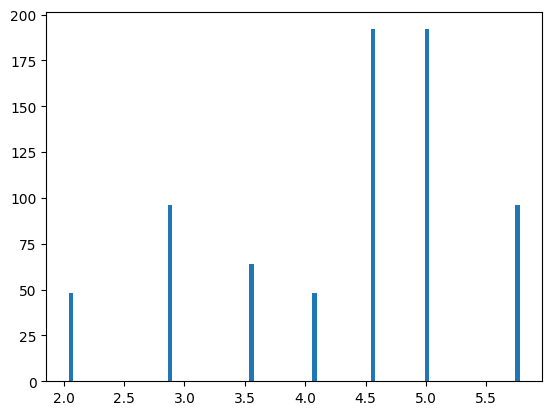

In [ ]:
print(len(distance_list[distance_list < 5.95]))
_ = plt.hist(distance_list[distance_list < 5.95], bins = 100)

#### ASE's implementation

736

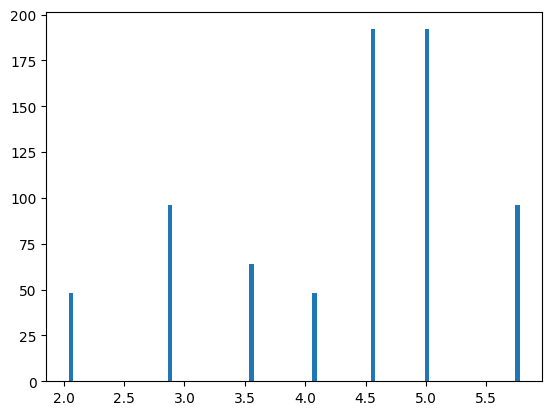

In [ ]:
from ase.neighborlist import neighbor_list

ii, jj, dd = neighbor_list('ijd', atoms, 5.95, self_interaction=False)

_ = plt.hist(dd, bins = 100)

len(dd)

### Task 3: Nearest neighbor

Write a function that calculates a minimum distance for each site in a given structure and returns its value and the nearest neighbor symbol

In [ ]:

def _get_minimum_distances(atoms, cutoff):

    """
    This function finds the nearest neighbor for each site in a given structure

    Params
    ------

    atoms: Atoms
        crystal structure
    cutoff float
        cutoff radius

    Returns
    -------

    list with the source atom chemical symbols,
    list with the nearest neighbor chemical symbols, and
    list with the distances between the source and the nearest neighbor

    """

    pass

_get_minimum_distances(atoms, 5.0)

#### The killer feature of the ASE package is the calculators and optimizers. We will discuss these in Seminar #9.

- https://wiki.fysik.dtu.dk/ase/ase/calculators/calculators.html

- https://wiki.fysik.dtu.dk/ase/ase/optimize.html

### Pymatgen: Intro
documentation: https://pymatgen.org/

In [ ]:
from pymatgen.core import Structure
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt

st = Structure.from_file('data/LiF.cif')
st

atoms = read('data/LiF.cif')

while the Atoms object is a structure of arrays, the Structure object is an array of structures

In [ ]:
atoms[atoms.numbers == 3]

Atoms(symbols='Li4', pbc=True, cell=[4.08342715, 4.08342715, 4.08342715], spacegroup_kinds=...)

In [ ]:
st[np.array(st.atomic_numbers) == 3] # we cannot handle the Structure in a similar way

TypeError: only integer scalar arrays can be converted to a scalar index

i.e. it's not as handy, but it has a lot more functionality (see the documentation)

In [ ]:
for site in st.sites:
    print(site.frac_coords, site.specie)

[0. 0. 0.] Li+
[0.5 0.5 0. ] Li+
[0.5 0.  0.5] Li+
[0.  0.5 0.5] Li+
[0.  0.  0.5] F-
[0.5 0.  0. ] F-
[0.  0.5 0. ] F-
[0.5 0.5 0.5] F-


In [ ]:
st.lattice

Lattice
    abc : 4.08342715 4.08342715 4.08342715
 angles : 90.0 90.0 90.0
 volume : 68.0886049327043
      A : 4.08342715 0.0 2.5003779943994496e-16
      B : 6.566651688219516e-16 4.08342715 2.5003779943994496e-16
      C : 0.0 0.0 4.08342715
    pbc : True True True

In [ ]:
st.lattice.matrix - atoms.cell

array([[0.00000000e+00, 0.00000000e+00, 2.50037799e-16],
       [6.56665169e-16, 0.00000000e+00, 2.50037799e-16],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [ ]:
st.volume

68.0886049327043

### Neighbor list using pymatgen and Voronoi partitioning

Motivation:
- crystal structures are very different, there is no a universal cutoff radius value for every system

- i.e. the cutoff radius is a parameter that we want to get rid of

- we can do it with the Voronoi partitioning scheme

<img src="https://thumb.wikimedia.org/wikipedia/commons/thumb/5/54/Euclidean_Voronoi_diagram.svg/1280px-Euclidean_Voronoi_diagram.svg.png" width="500">

<img src="https://wikimedia.org/api/rest_v1/media/math/render/svg/e93fab6a313bda86759f7c11e27881aa4c33e56e" width="500">




#### Approximate solution
source: https://github.com/mcs-cice/IonExplorer2/blob/main/geometry.py

In [ ]:
from scipy.spatial import Voronoi
import itertools

def find_vneighbors(points, central_points, key=1, min_dist=-float("inf"), max_dist=float("inf")):


    """
     Parameter mod can takes values 1, 2, or 3 that correspond to the
    search for domains adjacent by vertices, edges or faces.
    """

    neighbors = {i: None for i in central_points}
    vor = Voronoi(points)
    for i in central_points:
        cp = points[i]
        region = vor.regions[vor.point_region[i]]
        if -1 in region:
            raise ValueError("The domain for \"" + str(i) + "\" point is not closed!")
        local_neighbors = []
        for j in range(len(points)):
            numb_common_vertices = len(np.intersect1d(region, vor.regions[vor.point_region[j]]))
            if i != j and numb_common_vertices >= key and min_dist < np.linalg.norm(cp - points[j]) < max_dist:
                local_neighbors.append(j)
        neighbors[i] = local_neighbors
    return neighbors




atoms = read('data/LiF.cif')
points = []
offsets = tuple(list(itertools.product(
                                        [-1, 0, 1],
                                        [-1, 0, 1],
                                        [-1, 0, 1],
                                        )
                    )
                )


central_points_ids = []
for i, offset in enumerate(offsets):
    points.append(atoms.positions + np.dot(offset, atoms.cell))
    if offset == (0, 0, 0):
        central_points_ids = np.arange(len(atoms) * i, len(atoms) * (i + 1))

points = np.vstack(points)

nn = find_vneighbors(points, central_points_ids, key=3, min_dist=-float("inf"), max_dist=float("inf"))


In [ ]:
source_list = []
target_list = []
distance_list = []
for source in nn.keys():
    for target in nn[source]:
        source_list.append(source)
        target_list.append(target)
        d = np.linalg.norm(points[source] - points[target])
        distance_list.append(d)

2.041713575 2.041713575
48


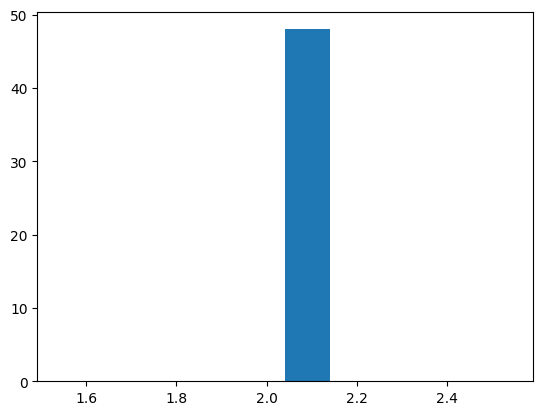

In [ ]:
print(min(distance_list), max(distance_list))
print(len(distance_list))

_ = plt.hist(distance_list)

#### Pymatgen's solution

In [ ]:
from pymatgen.analysis.local_env import VoronoiNN

In [ ]:
calc = VoronoiNN()
voro_data = calc.get_all_voronoi_polyhedra(st)

In [ ]:
type(voro_data)

list

In [ ]:
voro_data[0][1187]

{'site': PeriodicSite: F1 (F-) (3.283e-16, 2.042, 1.25e-16) [0.0, 0.5, 0.0],
 'normal': array([1.60812265e-16, 1.00000000e+00, 6.12323400e-17]),
 'solid_angle': np.float64(2.0943951023931966),
 'volume': np.float64(1.4185126027646726),
 'face_dist': np.float64(1.0208567875),
 'area': np.float64(4.16859432233928),
 'n_verts': 4,
 'verts': [164, 744, 743, 472],
 'adj_neighbors': [981, 817, 816, 1020]}

get voronoi polyhedra data for a specific site in a structure

In [ ]:
site_id = 4
voro_data_site = calc.get_voronoi_polyhedra(st, site_id)

In [ ]:
voro_data_site

{1: {'site': PeriodicNeighbor: Li0 (Li+) (-2.984, 0.0, 2.984) [-0.5, 0.0, 0.5],
  'normal': array([-1.,  0.,  0.]),
  'solid_angle': np.float64(2.0943951023931966),
  'volume': np.float64(4.4291732385857),
  'face_dist': np.float64(1.4920887075),
  'area': np.float64(8.905314844196084),
  'n_verts': 4,
  'verts': [285, 286, 288, 287],
  'adj_neighbors': [2, 3, 5, 4]},
 2: {'site': PeriodicNeighbor: Li0 (Li+) (-4.799e-16, -2.984, 2.984) [0.0, -0.5, 0.5],
  'normal': array([-1.60812265e-16, -1.00000000e+00,  0.00000000e+00]),
  'solid_angle': np.float64(2.0943951023931957),
  'volume': np.float64(4.429173238585699),
  'face_dist': np.float64(1.4920887075),
  'area': np.float64(8.905314844196083),
  'n_verts': 4,
  'verts': [285, 261, 262, 287],
  'adj_neighbors': [1, 3, 6, 4]},
 3: {'site': PeriodicNeighbor: Li0 (Li+) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0],
  'normal': array([ 0.,  0., -1.]),
  'solid_angle': np.float64(2.0943951023931953),
  'volume': np.float64(4.429173238585699),
  'face_dis

In [ ]:
ii, jj, dd = [], [], []
for source, data in enumerate(voro_data):
    for target in data.keys():
        ii.append(source)
        dd.append(2 * data[target]['face_dist'])

In [ ]:
print(min(dd), max(dd))
print(len(dd))

2.0417135749999997 2.041713575
48


#### We will explore more Pymatgen functionality at the next seminar (seminar #3).

### Task 4

Analyse the correlation between the Eg and X in LiX

Steps:
- Read the structures

- Collect Eg and Li-X bond lengths (using VoronoiNN)
    -  Eg vs. X data is stored in data/eg_vs_x.csv
- Plot Eg vs. Li-X
- Fit the line
- Report correlation coefficient


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from pymatgen.analysis.local_env import VoronoiNN
from scipy.stats import linregress

### Solutions to the tasks



<>:62: SyntaxWarning: invalid escape sequence '\A'
<>:62: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_720/2990978930.py:62: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel('Li-X bond length, $\AA$')


-0.9914764959836013


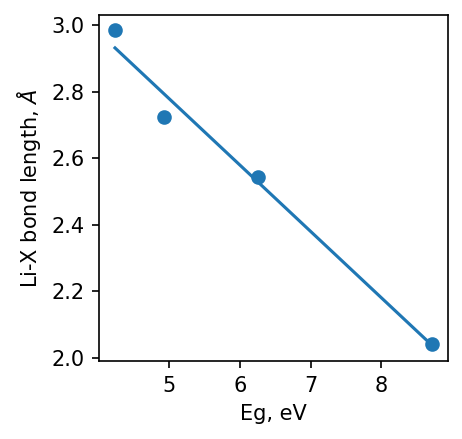

In [ ]:

# task 1
def unit_cell_volume(atoms):
    cell_matrix = atoms.cell
    v1, v2, v3 = cell_matrix[0, :], cell_matrix[1, :], cell_matrix[2, :]
    return np.dot(v1, np.cross(v2, v3))

# task 3
def _get_minimum_distances(atoms, cutoff):

    ii, jj, dd = neighbor_list('ijd', atoms, cutoff, self_interaction=False)


    source_ids = []
    nn_symbols = []
    d_min_list = []
    for i in np.unique(ii):
        d_min = dd[ii == i].min()

        nn_symbol = atoms.symbols[jj[ii==i][np.argwhere(dd[ii == i] == d_min).ravel()[0]]]

        d_min_list.append(d_min)
        source_ids.append(i)
        nn_symbols.append(nn_symbol)
    return source_ids, d_min_list, nn_symbols


# task 4
# read structure and Eg data

from scipy.stats import linregress

data = pd.read_csv('data/eg_vs_x.csv')

structures = []
for X in data.x:
    st = Structure.from_file(f'data/Li{X}.cif')
    structures.append(st)
data['structure'] = structures

# collect distances
li_x_mean_distances = []
for st in data.structure:
    calc = VoronoiNN()
    li_x_distances = []
    for i, site in enumerate(st.sites):
        if str(site.specie.element) == 'Li':
            poly_data = calc.get_voronoi_polyhedra(st, i)
            for nn in poly_data:
                li_x_distances.append(2 * poly_data[nn]['face_dist'])
    li_x_mean_distances.append(np.mean(li_x_distances))
data['li_x_distance'] = li_x_mean_distances

# plot data
fig, ax = plt.subplots(dpi = 150, figsize = (3, 3))
ax.scatter(data.eg, data.li_x_distance, label = 'data points')

res = linregress(data.eg, data.li_x_distance)
ax.plot(data.eg, data.eg * res.slope + res.intercept, label = 'linear fit')

ax.set_xlabel('Eg, eV')
ax.set_ylabel('Li-X bond length, $\AA$')

print(res.rvalue)


### Example from the slides

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mendeleev.fetch import fetch_table
from mendeleev.fetch import fetch_ionic_radii
from ase.io import read, write
from ase.neighborlist import neighbor_list
from ase.visualize import view
from ions.data import ionic_radii

table = fetch_table('elements')

df = pd.read_csv('data/eg_vs_x.csv')
df['symbol'] = df['x']

radii = []
for x in df.x:
    radii.append(ionic_radii[x][-1])

data['r_i'] = radii

X = df['x'].values
structures = []

for element in X:
    atoms = read(f'data/Li{element}.cif')
    structures.append(atoms)

from ase.build import make_supercell

sc = make_supercell(atoms, [[3, 0, 0 ], [0, 3, 0], [0, 0, 3]])
view(sc, viewer='x3d')


def get_li_x_bond_length(atoms, r_cut = 3.0):

    li_ids = np.where(atoms.symbols == 'Li')[0].ravel()

    ii, jj, dd = neighbor_list('ijd', atoms,  r_cut, self_interaction=False)

    min_distance = []
    for index in li_ids:
        min_distance.append(dd[ii == index].min())

    return min_distance

min_distance = get_li_x_bond_length(atoms)

li_x_distance = []
for atoms in structures:
    li_x_distance.append(np.mean(get_li_x_bond_length(atoms)))


df['li_x_bond_length'] = li_x_distance

df = table[['symbol', 'en_pauling', 'en_allen']].merge(df)


plt.rcParams['font.sans-serif'] = "Arial"
# Then, "ALWAYS use sans-serif fonts"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.size'] = 16

#plt.rcParams.update({'font.family': 'Sans-Serif'})
fig, ax = plt.subplots(figsize =(8, 3), dpi = 300)
ax.grid(zorder = -1, alpha = 1.0, axis = 'x', color = 'w')
# Horizontal Bar Plot
ax.barh(df.x, df.eg)
ax.set_xlabel('Eg, eV')
plt.tight_layout()
#fig.savefig('/Users/artemdembitskiy/Desktop/projects/intro-to-materials-informatics/src/lectures/lecture2/figures/eg_trend.png')


from scipy.stats import linregress

plt.rcParams['font.size'] = 11
fig, (ax, ax2) = plt.subplots(dpi = 600, figsize = (5, 3), ncols = 2, sharey = True)
ax.scatter(df.li_x_bond_length, df.eg, label = 'measured', color = 'darkred', alpha = 0.5)


res = linregress(df.li_x_bond_length, df.eg)
ax.plot(df.li_x_bond_length, df.li_x_bond_length * res.slope + res.intercept, label = 'fit', zorder = -1)

ax.set_xlabel('Li-X bond length, $\AA$')
ax.set_ylabel('Eg, eV')

res = linregress(df.en_pauling, df.eg)
ax2.scatter(df.en_pauling, df.eg, color = 'darkcyan', alpha = 0.5)
ax2.plot(df.en_pauling, df.en_pauling * res.slope + res.intercept, label = 'fit', zorder = -1)
ax2.set_xlabel('Electronegativity (Pauling)')
ax.legend(frameon = False)

plt.tight_layout()

#fig.savefig('/Users/artemdembitskiy/Desktop/projects/intro-to-materials-informatics/src/lectures/lecture2/figures/eg_correlation.png')



#### Are Li-X bond length and X electronegativity correlated?